
# AeroTwin — Feature Dataset EDA

A comprehensive exploratory data analysis of the three EUROCONTROL PRC 2025 featured datasets used to train and evaluate AeroTwin's physics-informed fuel-burn models.

| Dataset | File | Rows | Split | Period |
|---------|------|-----:|-------|--------|
| **Train** | `featured_dataset.parquet` | 119,032 | Train | Apr–Aug 2025 |
| **Rank** | `featured_dataset_rank.parquet` | 24,158 | Rank (Sep) | Sep 2025 |
| **Final** | `featured_dataset_final.parquet` | 37,170 | Final (Oct) | Oct 2025 |

**Target variable:** `actual_fuel_kg` — fuel burned per interval (kg).  
**Physics baseline:** `physics_fuel_kg` — OpenAP fuel-flow estimate (kg).  
**Residual:** `residual_kg = actual_fuel_kg - physics_fuel_kg`.



## 0. Setup — paths, imports, config


In [115]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

def _find_project_root(start: Path | None = None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / "pyproject.toml").exists():
            return cand
    return start

_start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
ROOT = _find_project_root(_start)
DATA_DIR = ROOT / "experiments" / "01_data_exploration"

print("ROOT     =", ROOT)
print("DATA_DIR =", DATA_DIR)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "axes.titlesize": 11,
                     "axes.titleweight": "bold", "axes.labelsize": 10})

SPLIT_ORDER = ["train", "rank", "final"]
SPLIT_LABEL = {"train": "Train (Apr-Aug)", "rank": "Rank (Sep)", "final": "Final (Oct)"}
SPLIT_COLOR = {"train": "#2e7d32", "rank": "#1f4e79", "final": "#b26a00"}
FILES: dict[str, Path] = {
    "train": DATA_DIR / "featured_dataset.parquet",
    "rank": DATA_DIR / "featured_dataset_rank.parquet",
    "final": DATA_DIR / "featured_dataset_final.parquet",
}
print("\nData files:")
for k, v in FILES.items():
    print(f"  {k:6s} exists={v.exists()}  {v}")

ROOT     = /Volumes/Fire/Projects 2.0/ZeroPing
DATA_DIR = /Volumes/Fire/Projects 2.0/ZeroPing/experiments/01_data_exploration

Data files:
  train  exists=True  /Volumes/Fire/Projects 2.0/ZeroPing/experiments/01_data_exploration/featured_dataset.parquet
  rank   exists=True  /Volumes/Fire/Projects 2.0/ZeroPing/experiments/01_data_exploration/featured_dataset_rank.parquet
  final  exists=True  /Volumes/Fire/Projects 2.0/ZeroPing/experiments/01_data_exploration/featured_dataset_final.parquet


### 0.1 The dataset I/O layer — load helper


In [116]:

def load_all() -> dict[str, pl.DataFrame]:
    """Load all three datasets; fail loudly if any is missing."""
    datasets: dict[str, pl.DataFrame] = {}
    for split, path in FILES.items():
        if not path.exists():
            raise FileNotFoundError(f"{split} not found at {path}. "
                                    "Ensure the featured parquets are under experiments/01_data_exploration/")
        datasets[split] = pl.read_parquet(path)
    return datasets

DATASETS = load_all()

for split in SPLIT_ORDER:
    df = DATASETS[split]
    print(f"{split:6s}  rows={df.shape[0]:>7,}  cols={df.shape[1]:>3}  "
          f"flights={df['flight_id'].n_unique():>5,}")



train   rows=119,032  cols= 62  flights=10,000
rank    rows= 24,158  cols= 62  flights=1,881
final   rows= 37,170  cols= 62  flights=2,824


## 1. Data-quality overview


### 1.1 Schema & column types


In [117]:

df0 = DATASETS["train"]
schema = pd.DataFrame(
    {"col": df0.columns,
     "dtype": [str(t) for t in df0.schema.values()],
     "type": [("numeric" if df0.schema[c] in (pl.Float64, pl.Float32, pl.Int64, pl.Int32)
               else "categorical" if df0.schema[c] in (pl.String, pl.Boolean)
               else "timestamp" if df0.schema[c] == pl.Datetime("us") else "other")
              for c in df0.columns]}
)
schema



,col,dtype,type
0,actual_fuel_kg,Float64,numeric
1,physics_fuel_kg,Float64,numeric
2,residual_kg,Float64,numeric
3,flight_id,String,categorical
4,aircraft_type,String,categorical
...,...,...,...
57,temperature_k,Float64,numeric
58,pressure_pa,Float64,numeric
59,isa_deviation_k,Float64,numeric
60,density_altitude_m,Float64,numeric


In [118]:

print("Feature-group breakdown")
group_map = {
    "target": ["actual_fuel_kg", "physics_fuel_kg", "residual_kg"],
    "id": ["flight_id", "aircraft_type", "origin_icao", "destination_icao", "method", "interval_idx"],
    "trajectory/kinematics": [c for c in df0.columns if any(k in c for k in
        ("altitude", "groundspeed", "vertical_rate", "fraction", "tas", "alt_used", "vs_used", "n_traj_pts"))],
    "physics": [c for c in df0.columns if c.startswith("physics_")],
    "mass": [c for c in df0.columns if "mass" in c.lower() or "r3_" in c],
    "energy": [c for c in df0.columns if "energy" in c.lower() or "specific_energy" in c],
    "operational": [c for c in df0.columns if any(k in c.lower() for k in
        ("cruise", "climb", "descent", "efficiency", "holding", "segment", "stab", "distance", "path", "level"))],
    "weather": [c for c in df0.columns if any(k in c.lower() for k in
        ("wind", "temperature", "pressure", "isa", "density"))],
}
for g, cols in group_map.items():
    print(f"  {g:20s} ({len(cols):2d})  {cols}")



Feature-group breakdown
  target               ( 3)  ['actual_fuel_kg', 'physics_fuel_kg', 'residual_kg']
  id                   ( 6)  ['flight_id', 'aircraft_type', 'origin_icao', 'destination_icao', 'method', 'interval_idx']
  trajectory/kinematics (22)  ['start_fraction_of_flight', 'end_fraction_of_flight', 'n_traj_pts', 'mean_altitude', 'median_altitude', 'max_altitude', 'std_altitude', 'mean_groundspeed', 'std_groundspeed', 'max_groundspeed', 'mean_vertical_rate', 'std_vertical_rate', 'climb_fraction', 'cruise_fraction', 'descent_fraction', 'tas_used', 'alt_used', 'vs_used', 'tas_std', 'vertical_rate_std', 'altitude_stability', 'density_altitude_m']
  physics              ( 2)  ['physics_fuel_kg', 'physics_wind_adj_kg']
  mass                 ( 1)  ['ref_mass_kg']
  energy               ( 9)  ['mean_potential_energy_j', 'mean_kinetic_energy_j', 'mean_specific_energy_jpkg', 'specific_energy_start', 'specific_energy_end', 'energy_change_jpkg', 'energy_rate_jpkg_s', 'energy_efficienc

### 1.2 Completeness — missing values


In [119]:

def missing_table(df: pl.DataFrame) -> pd.DataFrame:
    n = df.height
    rows = []
    for c in df.columns:
        n_miss = df[c].null_count()
        rows.append({"col": c, "n_missing": n_miss, "frac": round(n_miss / n, 4)})
    return pd.DataFrame(rows)

# joined completeness across splits
completeness = {}
for split in SPLIT_ORDER:
    mt = missing_table(DATASETS[split]).set_index("col")
    completeness[split] = mt
comp_df = pd.concat({s: v["n_missing"] for s, v in completeness.items()}, axis=1)
comp_frac = pd.concat({s: v["frac"] for s, v in completeness.items()}, axis=1)
# show columns with any missing
any_missing = comp_frac[(comp_frac > 0).any(axis=1)].sort_values("train", ascending=False)
any_missing



,train,rank,final
col,,,
mean_vertical_rate,0.3587,0.2607,0.2535
mean_groundspeed,0.3587,0.2607,0.2535
climb_efficiency,0.3587,0.3528,0.3684
max_groundspeed,0.3587,0.2607,0.2535
holding_indicator,0.3587,0.0000,0.0000
mean_altitude,0.0332,0.0017,0.0016
median_altitude,0.0332,0.0017,0.0016
max_altitude,0.0332,0.0017,0.0016
tas_std,0.0251,0.0000,0.0000


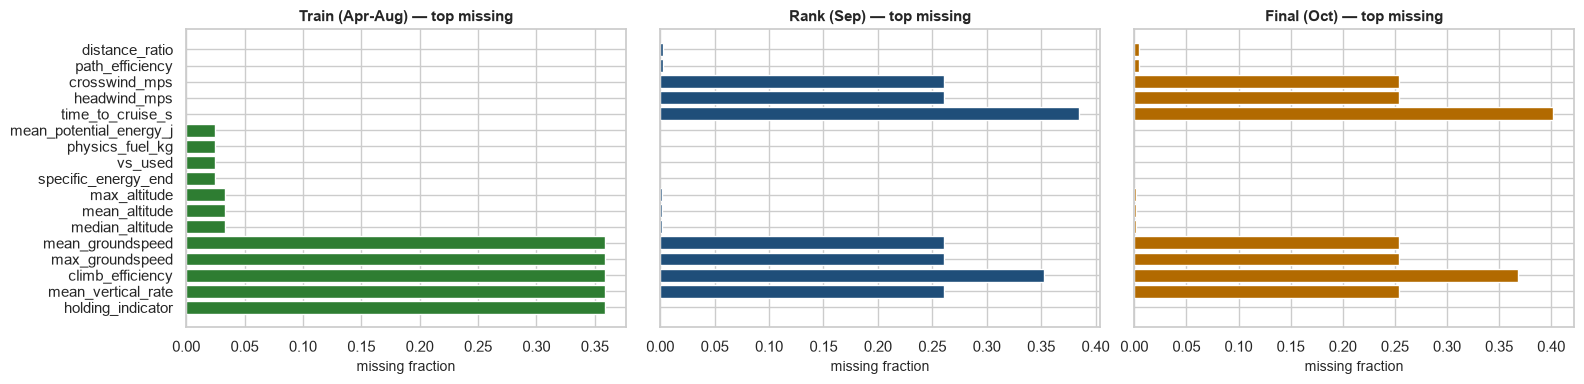

In [120]:

# Bar: overall completeness by split
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, split in zip(axes, SPLIT_ORDER):
    mt = missing_table(DATASETS[split])
    mt = mt.sort_values("frac", ascending=False).head(12)
    ax.barh(mt["col"], mt["frac"], color=SPLIT_COLOR[split])
    ax.set_title(f"{SPLIT_LABEL[split]} — top missing")
    ax.set_xlabel("missing fraction")
fig.tight_layout()



### 1.3 Duplicates & integrity


In [121]:

for split in SPLIT_ORDER:
    df = DATASETS[split]
    dup_ids = df.group_by(["flight_id","interval_idx"]).len().filter(pl.col("len")>1)
    n_null_target = df["actual_fuel_kg"].null_count()
    print(f"{split:6s}  duplicate (flight_id,interval_idx): {dup_ids.height:>4}  |  "
          f"null target rows: {n_null_target:>5}")



train   duplicate (flight_id,interval_idx):    0  |  null target rows:     0
rank    duplicate (flight_id,interval_idx):    0  |  null target rows:     0
final   duplicate (flight_id,interval_idx):    0  |  null target rows:     0


## 2. Target variable — `actual_fuel_kg`


### 2.1 Summary statistics


In [122]:

target_stats = {}
for split in SPLIT_ORDER:
    s = DATASETS[split]["actual_fuel_kg"]
    target_stats[split] = {
        "count": s.len(), "mean": round(s.mean(),1), "std": round(s.std(),1),
        "min": round(s.min(),1), "p25": round(s.quantile(0.25),1),
        "median": round(s.median(),1), "p75": round(s.quantile(0.75),1),
        "p95": round(s.quantile(0.95),1), "p99": round(s.quantile(0.99),1),
        "max": round(s.max(),1), "skew": round(s.skew(),2), "kurtosis": round(s.kurtosis(),2),
    }
pd.DataFrame(target_stats).T



,count,mean,std,min,p25,median,p75,p95,p99,max,skew,kurtosis
train,119032.0,571.3,894.1,0.5,100.0,217.0,600.0,2200.0,4490.6,32205.0,4.30,41.76
rank,24158.0,420.7,773.4,0.5,90.7,163.3,399.2,1700.0,4127.7,14771.0,4.80,36.38
final,37170.0,414.2,773.1,0.5,90.3,163.3,393.3,1647.0,4200.0,13228.0,4.92,36.05


### 2.2 Distribution, log-scale, and density


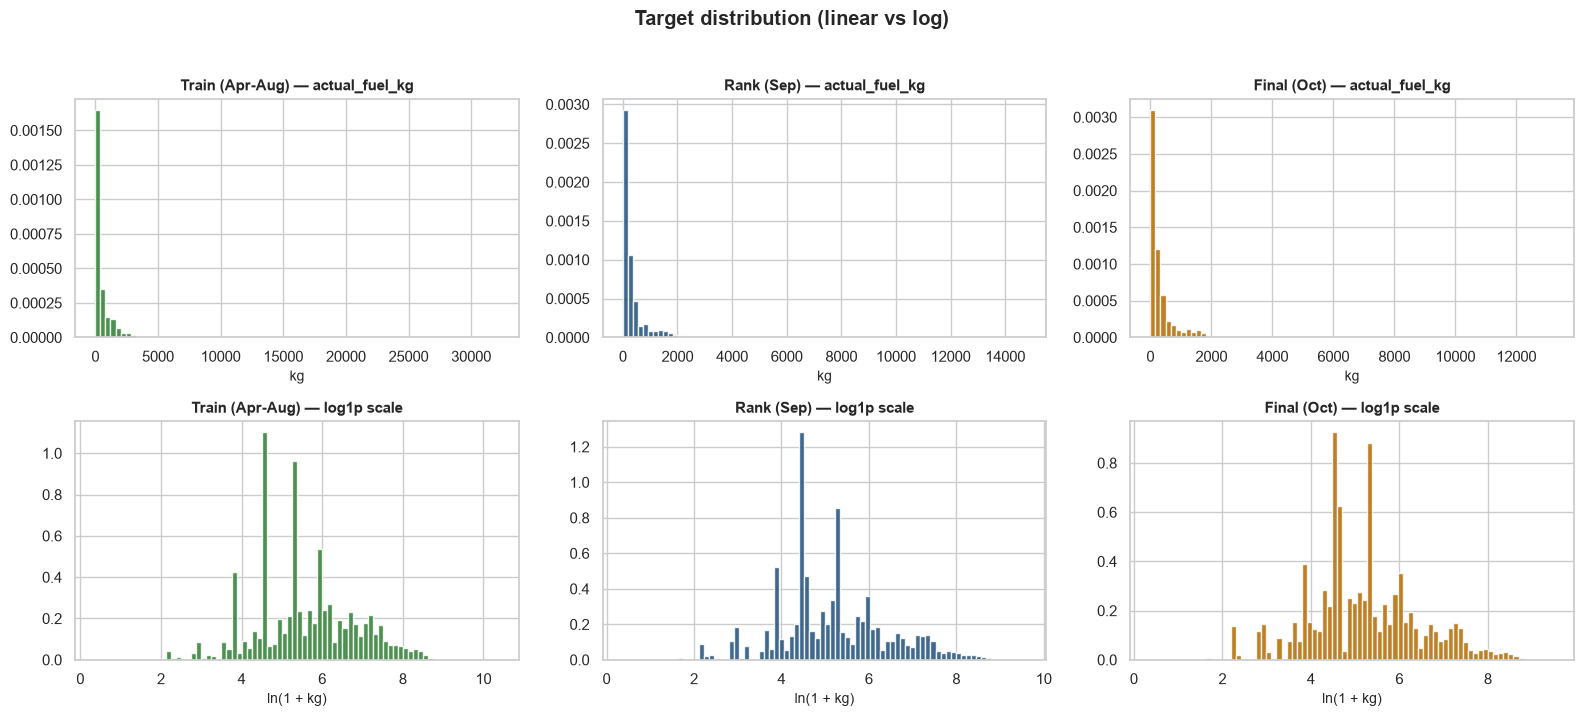

In [123]:

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for i, split in enumerate(SPLIT_ORDER):
    x = DATASETS[split]["actual_fuel_kg"].drop_nulls().to_numpy()
    # linear
    axes[0,i].hist(x, bins=80, color=SPLIT_COLOR[split], alpha=0.85, density=True)
    axes[0,i].set_title(f"{SPLIT_LABEL[split]} — actual_fuel_kg")
    axes[0,i].set_xlabel("kg")
    # log
    axes[1,i].hist(np.log1p(x), bins=80, color=SPLIT_COLOR[split], alpha=0.85, density=True)
    axes[1,i].set_title(f"{SPLIT_LABEL[split]} — log1p scale")
    axes[1,i].set_xlabel("ln(1 + kg)")
fig.suptitle("Target distribution (linear vs log)", y=1.02, fontweight="bold")
fig.tight_layout()



### 2.3 Skewness diagnosis


In [124]:

# Heaviness of the target drives MSE/RMSE; skew indicates asymmetric error regimes
skew_df = pd.DataFrame({s: {"skew": round(DATASETS[s]["actual_fuel_kg"].skew(),3),
                            "mean>median": float(DATASETS[s]["actual_fuel_kg"].mean() >
                                                 DATASETS[s]["actual_fuel_kg"].median())}
                        for s in SPLIT_ORDER})
skew_df.T



,skew,mean>median
train,4.305,1.0
rank,4.804,1.0
final,4.916,1.0


### 2.4 Target by aircraft mass class


In [125]:

WIDE = {"A332","A333","A359","A388","B772","B77L","B77W","B788","B789","MD11"}
def body_class(t):
    return "widebody" if str(t) in WIDE else "narrowbody"

df_body = df0.with_columns(pl.col("aircraft_type").map_elements(body_class, return_dtype=pl.String).alias("body"))
df_body.group_by("body").agg(pl.col("actual_fuel_kg").mean().alias("mean_kg"),
                             pl.len().alias("n_intervals")).sort("n_intervals", descending=True)



body,mean_kg,n_intervals
str,f64,u32
"""narrowbody""",240.08406,77609
"""widebody""",1191.742479,41423


## 3. Record structure — flights, aircraft, routes, methods


### 3.1 Aircraft-type composition


In [126]:

type_counts = {}
for split in SPLIT_ORDER:
    vc = DATASETS[split]["aircraft_type"].value_counts()
    type_counts[split] = dict(zip(vc["aircraft_type"].to_list(), vc["count"].to_list()))
type_tbl = pd.DataFrame(type_counts).fillna(0).astype(int).sort_values("train", ascending=False)
type_tbl



,train,rank,final
A20N,35662,11961,17056
A320,28188,4938,7948
A359,22273,3577,5545
B788,7406,387,350
B738,7076,574,1266
A332,5064,805,1396
B789,2905,628,805
A21N,2870,147,792
A321,2406,122,146
B77W,1584,318,713


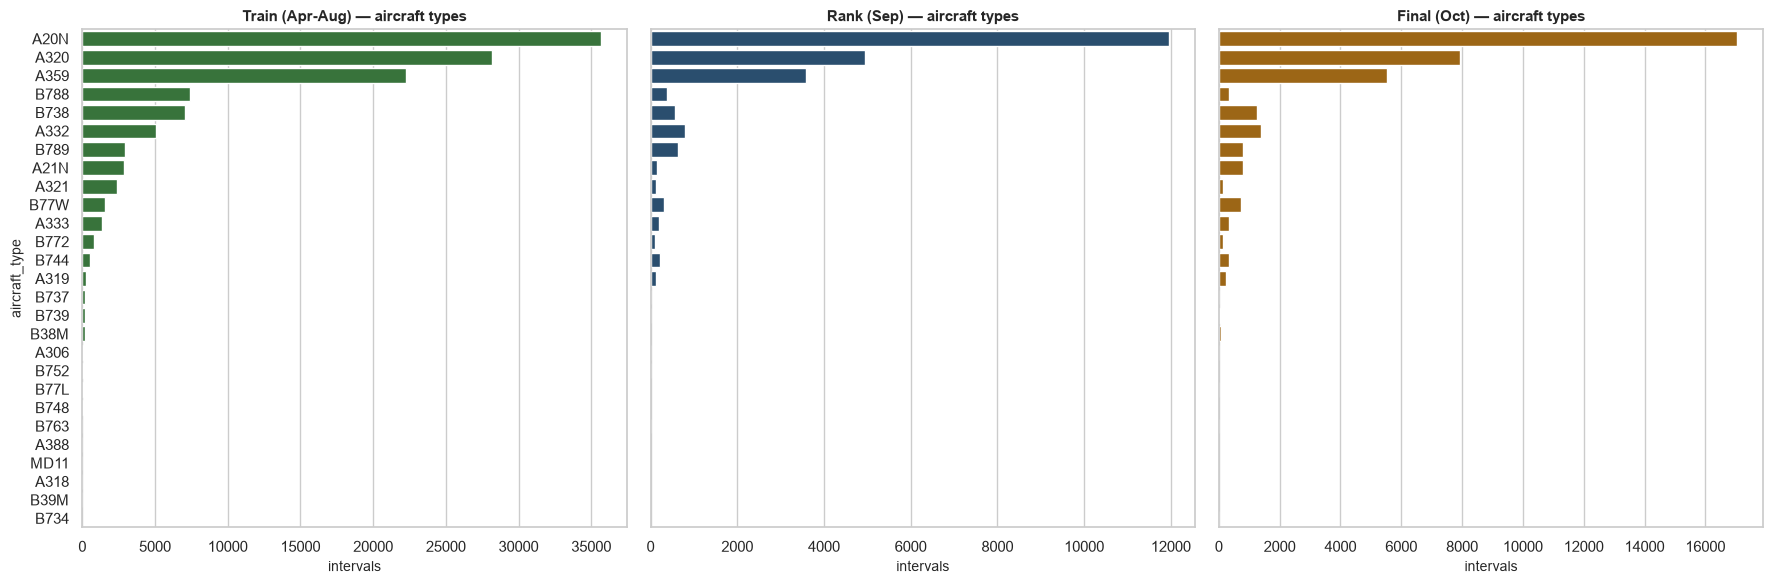

In [127]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ax, split in zip(axes, SPLIT_ORDER):
    vc = DATASETS[split]["aircraft_type"].value_counts().sort("count", descending=True).to_pandas()
    sns.barplot(data=vc, y="aircraft_type", x="count", ax=ax, color=SPLIT_COLOR[split])
    ax.set_title(f"{SPLIT_LABEL[split]} — aircraft types")
    ax.set_xlabel("intervals")
fig.tight_layout()



In [128]:

# Concentration = how dominated by a few types
for split in SPLIT_ORDER:
    vc = DATASETS[split]["aircraft_type"].value_counts().sort("count", descending=True)
    total = vc["count"].sum()
    top5_share = vc.head(5)["count"].sum() / total
    print(f"{split:6s}  types={vc.height:2d}  top-5 share={top5_share:.2%}")



train   types=26  top-5 share=84.52%
rank    types=19  top-5 share=90.69%
final   types=21  top-5 share=89.35%


### 3.2 Flights per type (entity granularity)


In [129]:
for split in SPLIT_ORDER:
    df = DATASETS[split]
    fpt = (df.group_by("aircraft_type")
            .agg(pl.col("flight_id").n_unique().alias("flights"),
                 pl.len().alias("intervals"))
            .sort("flights", descending=True))
    print(f"--- {split} ---")
    print(f"  total flights: {df['flight_id'].n_unique()}")
    print(f"  mean intervals/flight: {df.height / df['flight_id'].n_unique():.1f}")
    print(fpt.head(5).to_pandas().to_string(index=False))
    print()


--- train ---
  total flights: 10000
  mean intervals/flight: 11.9
aircraft_type  flights  intervals
         A20N     2862      35662
         A320     2673      28188
         A359     1452      22273
         B788      576       7406
         B738      521       7076

--- rank ---
  total flights: 1881
  mean intervals/flight: 12.8
aircraft_type  flights  intervals
         A20N      849      11961
         A320      403       4938
         A359      255       3577
         A332       76        805
         B738       61        574

--- final ---
  total flights: 2824
  mean intervals/flight: 13.2
aircraft_type  flights  intervals
         A20N     1151      17056
         A320      642       7948
         A359      365       5545
         B738      137       1266
         A332      106       1396



### 3.3 Route / airport network


In [130]:

for split in SPLIT_ORDER:
    df = DATASETS[split]
    n_orig = df["origin_icao"].n_unique(); n_dest = df["destination_icao"].n_unique()
    n_routes = df.select(pl.struct(["origin_icao","destination_icao"]).n_unique())[0,0]
    print(f"{split:6s}  origins={n_orig}  destinations={n_dest}  unique routes={n_routes}")

print("\nTop-10 most frequent routes (train)")
(df0.group_by(["origin_icao","destination_icao"]).len().sort("len", descending=True)
    .head(10).with_columns((pl.col("len")/df0.height*100).round(2).alias("%")))



train   origins=264  destinations=255  unique routes=1001
rank    origins=138  destinations=135  unique routes=387
final   origins=158  destinations=149  unique routes=466

Top-10 most frequent routes (train)


origin_icao,destination_icao,len,%
str,str,u32,f64
"""ZSPD""","""YSSY""",5295,4.45
"""MSLP""","""KIAD""",3407,2.86
"""KIAD""","""MSLP""",2744,2.31
"""SEGU""","""KJFK""",2158,1.81
"""NZAA""","""ZSPD""",2034,1.71
"""ZSPD""","""YMML""",1971,1.66
"""KJFK""","""MSLP""",1864,1.57
"""KJFK""","""SEGU""",1822,1.53
"""MSLP""","""KJFK""",1796,1.51


### 3.4 Label-source method


In [131]:

# `method` records how true-air-speed (and thus physics inputs) was inferred
method_tbl = {}
for split in SPLIT_ORDER:
    vc = DATASETS[split]["method"].value_counts()
    method_tbl[split] = dict(zip(vc["method"].to_list(), vc["count"].to_list()))
pd.DataFrame(method_tbl).fillna(0).astype(int).sort_values("train", ascending=False)



,train,rank,final
tas_from_mach,73841,16470,24425
tas_from_cas,19335,3530,6962
fallback_tas_200,13161,2774,3536
tas_from_gs,7469,454,837
no_coverage,2987,0,0
tas_from_mach_short,1837,831,1239
tas_from_cas_short,243,88,131
tas_from_gs_short,130,6,27
fallback_tas_200_short,29,5,13


In [132]:

# TAS-inference categories: short intervals vs full
method_tbl2 = {}
for split in SPLIT_ORDER:
    df = DATASETS[split]
    short = df["method"].str.contains("_short").fill_null(False).mean()
    print(f"{split:6s}  share of '_short' (short-interval) methods: {short:.2%}")



train   share of '_short' (short-interval) methods: 1.88%
rank    share of '_short' (short-interval) methods: 3.85%
final   share of '_short' (short-interval) methods: 3.79%


## 4. Temporal structure & phase composition


### 4.1 Flight-phase composition


In [133]:

for split in SPLIT_ORDER:
    vc = DATASETS[split]["phase"].value_counts(normalize=True)
    print(f"--- {SPLIT_LABEL[split]} ---")
    print(vc.to_pandas().to_string(index=False))
    print()



--- Train (Apr-Aug) ---
  phase  proportion
descent    0.126369
    NaN    0.025094
 cruise    0.422147
  climb    0.092790
unknown    0.333599

--- Rank (Sep) ---
  phase  proportion
 cruise    0.477150
  climb    0.117063
descent    0.145128
unknown    0.260659

--- Final (Oct) ---
  phase  proportion
 cruise    0.480872
descent    0.152220
  climb    0.113425
unknown    0.253484



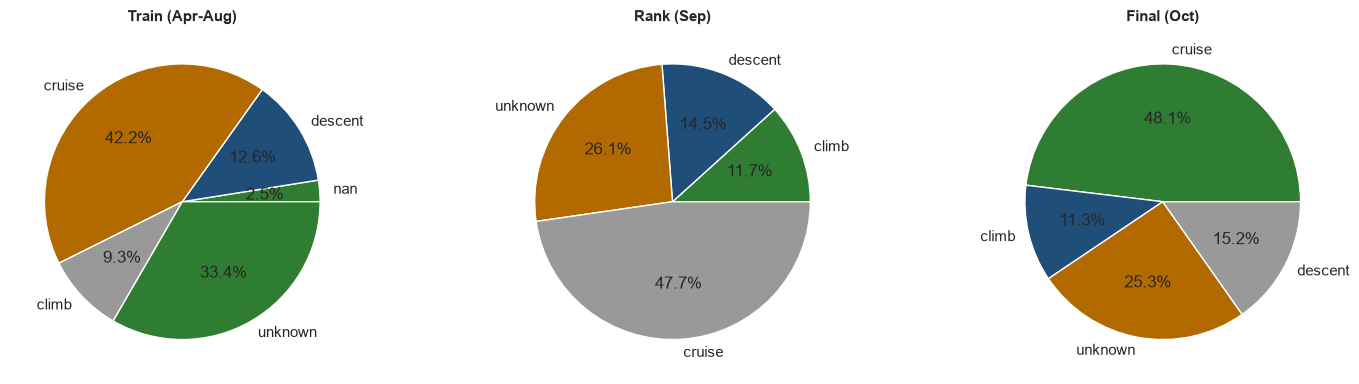

In [134]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, SPLIT_ORDER):
    vc = DATASETS[split]["phase"].value_counts(normalize=True).to_pandas()
    ax.pie(vc["proportion"], labels=list(vc["phase"]), autopct="%1.1f%%",
           colors=["#2e7d32","#1f4e79","#b26a00","#999999"])
    ax.set_title(SPLIT_LABEL[split])
fig.tight_layout()



### 4.2 Interval duration & start/end fractions


In [135]:

if "duration_s" in df0.columns:
    dur = {}
    for split in SPLIT_ORDER:
        d = DATASETS[split]["duration_s"]
        dur[split] = {"mean": round(d.mean(),0), "median": round(d.median(),0),
                      "p05": round(d.quantile(0.05),0), "p95": round(d.quantile(0.95),0),
                      "min": d.min(), "max": d.max()}
    pd.DataFrame(dur).T



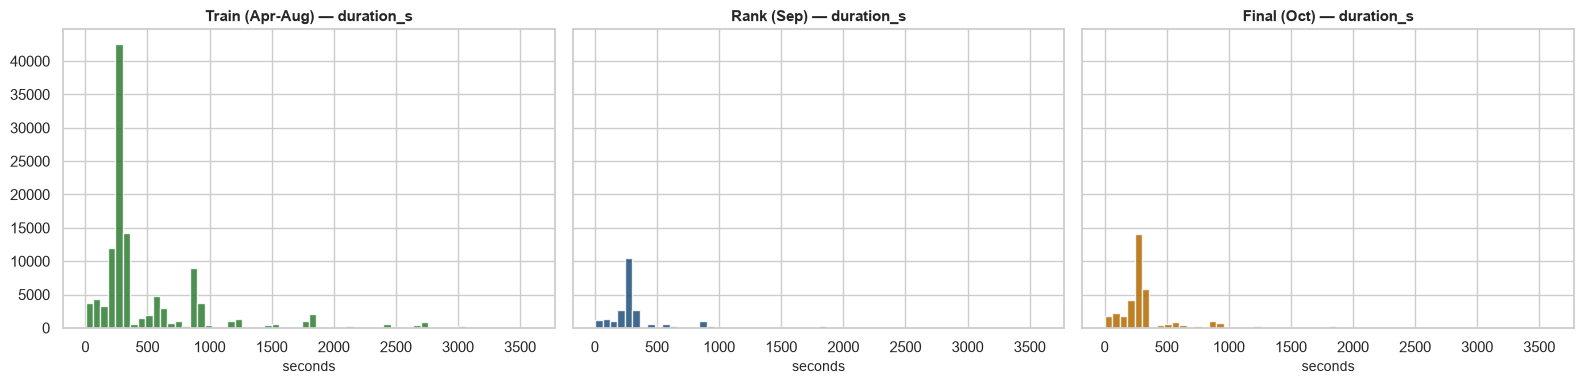

In [136]:

if "duration_s" in df0.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, split in zip(axes, SPLIT_ORDER):
        ax.hist(DATASETS[split]["duration_s"].to_numpy(), bins=60, color=SPLIT_COLOR[split], alpha=0.85)
        ax.set_title(f"{SPLIT_LABEL[split]} — duration_s"); ax.set_xlabel("seconds")
    fig.tight_layout()



### 4.3 Trajectory density


train   median pts/interval=272  share with <5 pts=36.03%
rank    median pts/interval=476  share with <5 pts=26.16%
final   median pts/interval=471  share with <5 pts=25.52%


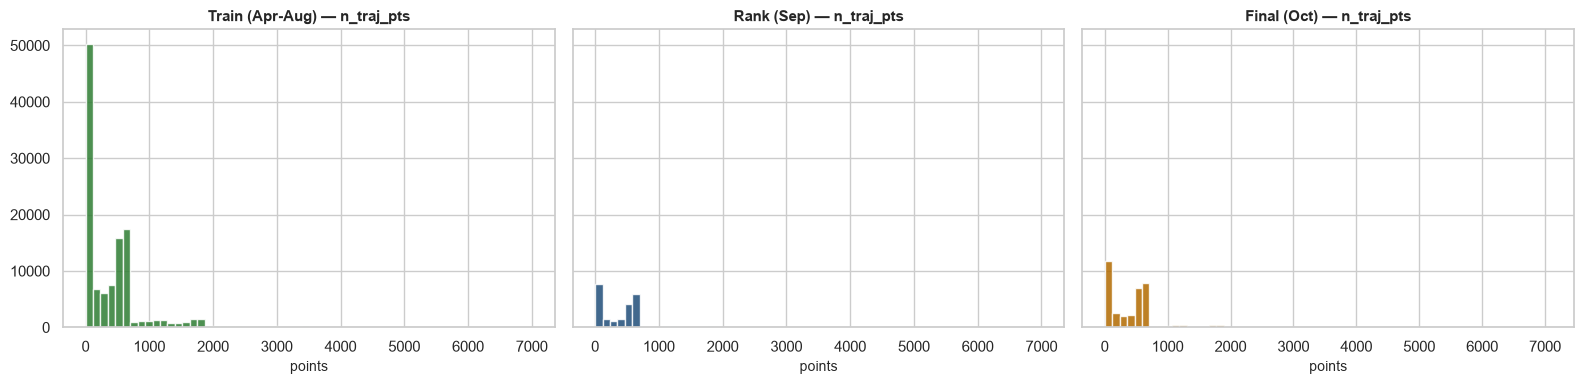

In [137]:

if "n_traj_pts" in df0.columns:
    # how many trajectory samples fall inside each interval
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, split in zip(axes, SPLIT_ORDER):
        ax.hist(DATASETS[split]["n_traj_pts"].to_numpy(), bins=60, color=SPLIT_COLOR[split], alpha=0.85)
        ax.set_title(f"{SPLIT_LABEL[split]} — n_traj_pts"); ax.set_xlabel("points")
    fig.tight_layout()

for split in SPLIT_ORDER:
    df = DATASETS[split]
    med = df["n_traj_pts"].median()
    sp = (df["n_traj_pts"] < 5).mean()
    print(f"{split:6s}  median pts/interval={med:.0f}  share with <5 pts={sp:.2%}")



## 5. Physics baseline — `physics_fuel_kg`


### 5.1 Physics error vs target


In [138]:

rows = []
for split in SPLIT_ORDER:
    df = DATASETS[split]
    y = df["actual_fuel_kg"].to_numpy()
    p = df["physics_fuel_kg"].to_numpy()
    mask = np.isfinite(p) & np.isfinite(y)
    y, p = y[mask], p[mask]
    err = p - y
    ss_res = np.sum(err**2); ss_tot = np.sum((y - y.mean())**2)
    rows.append({
        "split": split, "n": len(y),
        "physics MAE": round(np.abs(err).mean(),1),
        "physics RMSE": round(np.sqrt(np.mean(err**2)),1),
        "bias": round(err.mean(),2),
        "R2": round(1 - ss_res/ss_tot, 4),
    })
pd.DataFrame(rows)



,split,n,physics MAE,physics RMSE,bias,R2
0,train,115995,652.6,1550.4,621.74,-2.0020
1,rank,24158,451.5,1192.0,429.30,-1.3752
2,final,37170,485.4,1315.7,465.51,-1.8963


### 5.2 Residual distribution (physics vs actual)


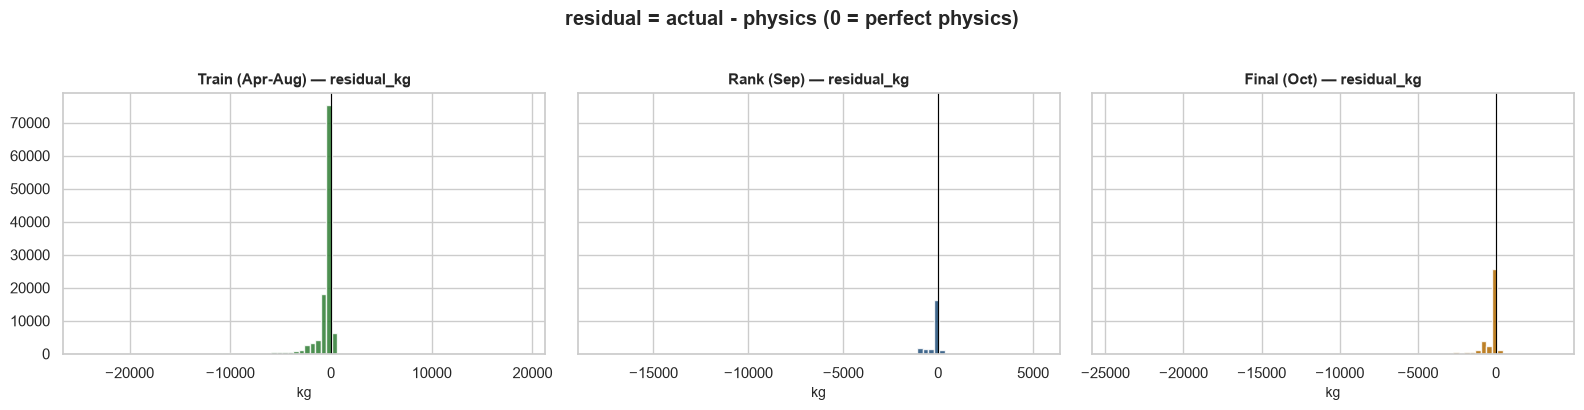

In [139]:

if "residual_kg" in df0.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, split in zip(axes, SPLIT_ORDER):
        x = DATASETS[split]["residual_kg"].drop_nulls().to_numpy()
        ax.hist(x, bins=80, color=SPLIT_COLOR[split], alpha=0.85)
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(f"{SPLIT_LABEL[split]} — residual_kg"); ax.set_xlabel("kg")
    fig.suptitle("residual = actual - physics (0 = perfect physics)", y=1.02, fontweight="bold")
    fig.tight_layout()



### 5.3 Physics error by phase


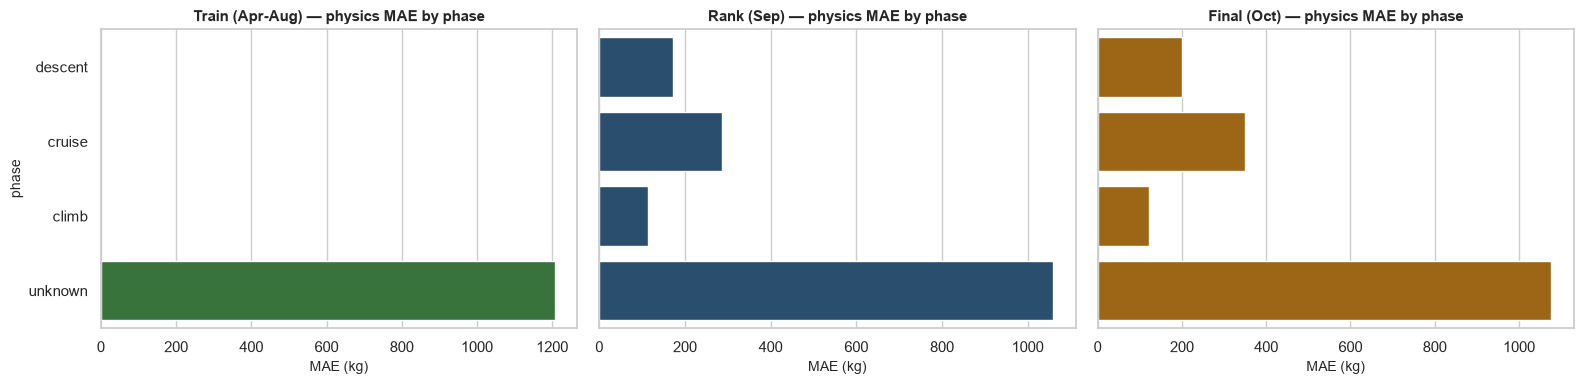

In [140]:

if {"phase","physics_fuel_kg","actual_fuel_kg"} <= set(df0.columns):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, split in zip(axes, SPLIT_ORDER):
        df = DATASETS[split]
        tmp = df.filter(pl.col("physics_fuel_kg").is_not_null())
        per = (tmp.with_columns(abs(pl.col("physics_fuel_kg")-pl.col("actual_fuel_kg")).alias("ae"))
                 .group_by("phase").agg(pl.col("ae").mean().alias("mae"))
                 .sort("mae", descending=True))
        sns.barplot(data=per.to_pandas(), y="phase", x="mae", ax=ax, color=SPLIT_COLOR[split])
        ax.set_title(f"{SPLIT_LABEL[split]} — physics MAE by phase"); ax.set_xlabel("MAE (kg)")
    fig.tight_layout()



## 6. Feature families & bivariate relationships


### 6.1 Correlation heatmap (numeric, train)


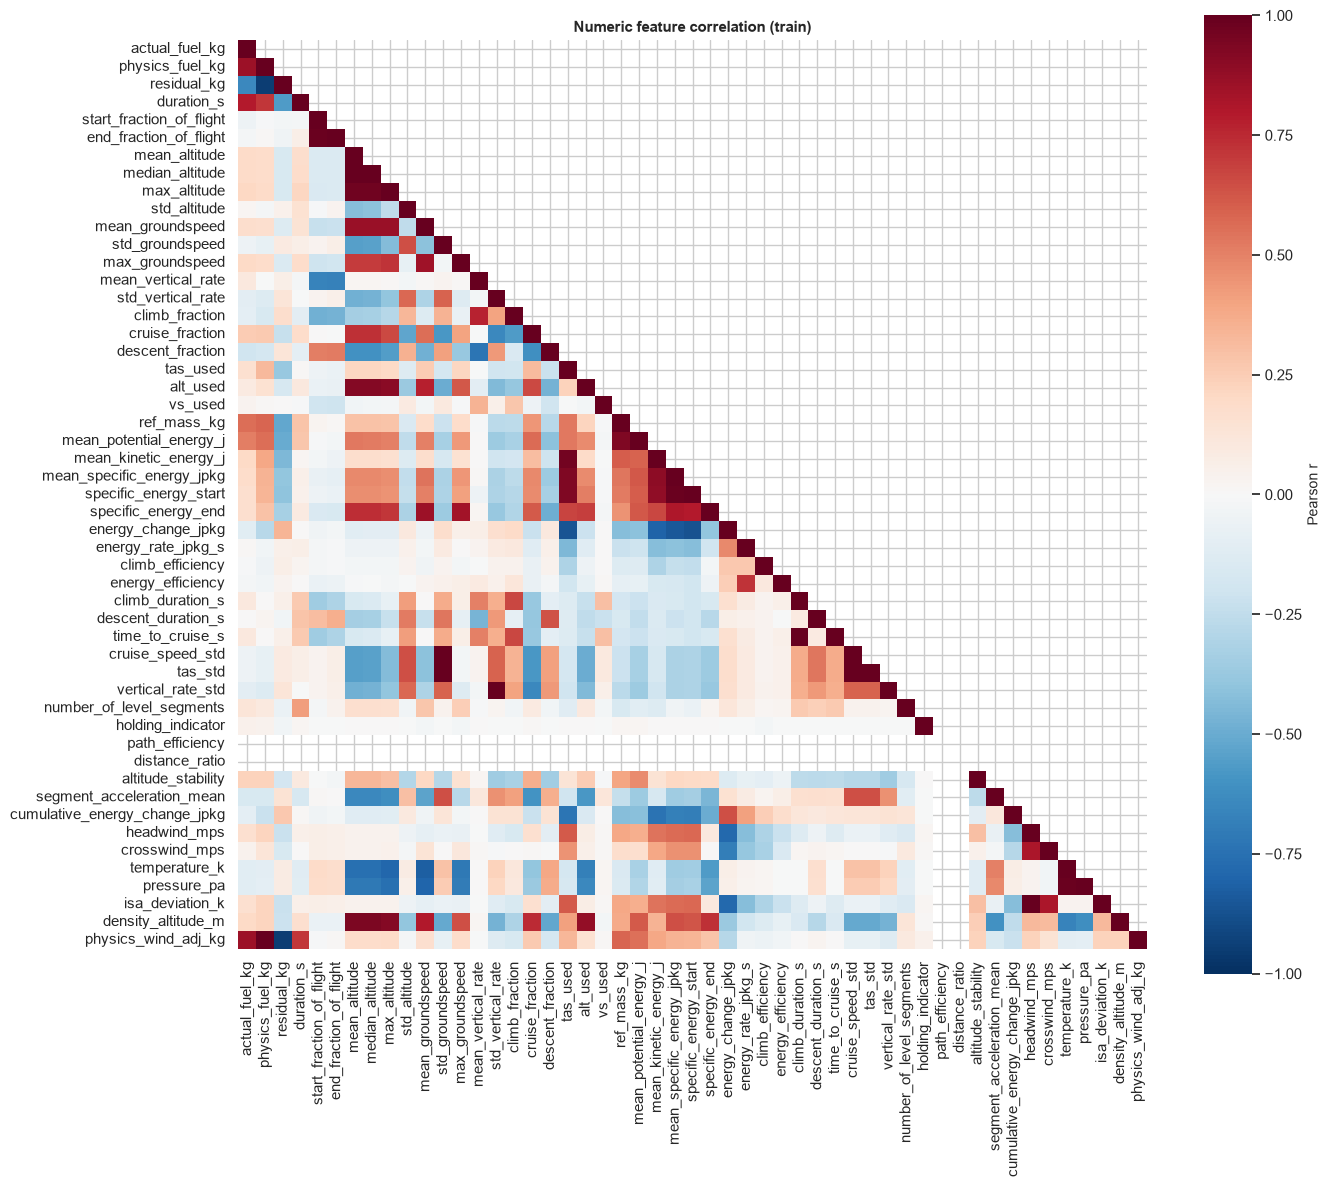

In [141]:

num_cols = [c for c in df0.columns if df0.schema[c] in (pl.Float64, pl.Float32)]
corr = df0.select(num_cols).to_pandas().corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label":"Pearson r"})
ax.set_title("Numeric feature correlation (train)")
fig.tight_layout()



### 6.2 Top features vs target


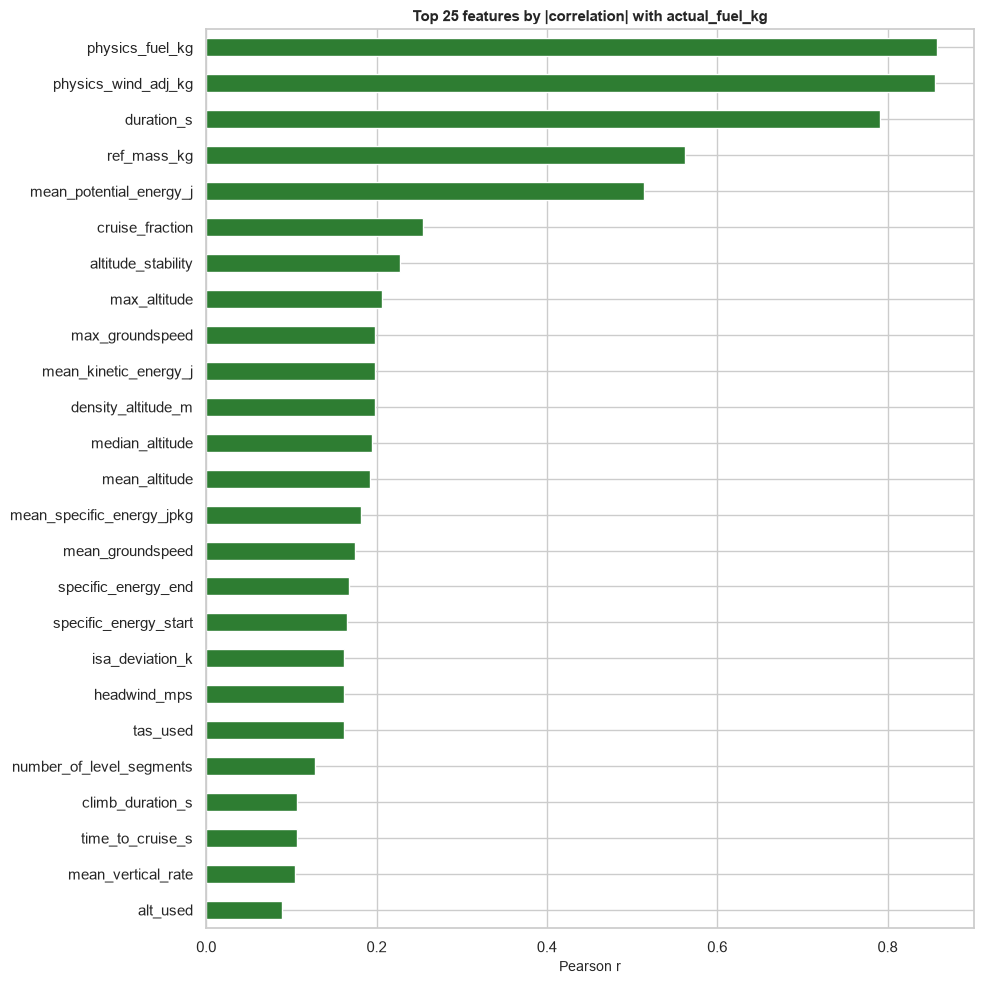

In [142]:

if "actual_fuel_kg" in df0.columns:
    tgt_corr = corr["actual_fuel_kg"].drop("actual_fuel_kg").sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 10))
    tgt_corr.head(25).plot.barh(color="#2e7d32", ax=ax)
    ax.invert_yaxis(); ax.set_title("Top 25 features by |correlation| with actual_fuel_kg")
    ax.set_xlabel("Pearson r")
    fig.tight_layout()



### 6.3 Energy-state features


In [143]:

energy_cols = [c for c in df0.columns if "energy" in c.lower()]
if energy_cols:
    pd.DataFrame({c: df0[c].drop_nulls().to_pandas().describe() for c in energy_cols}).T



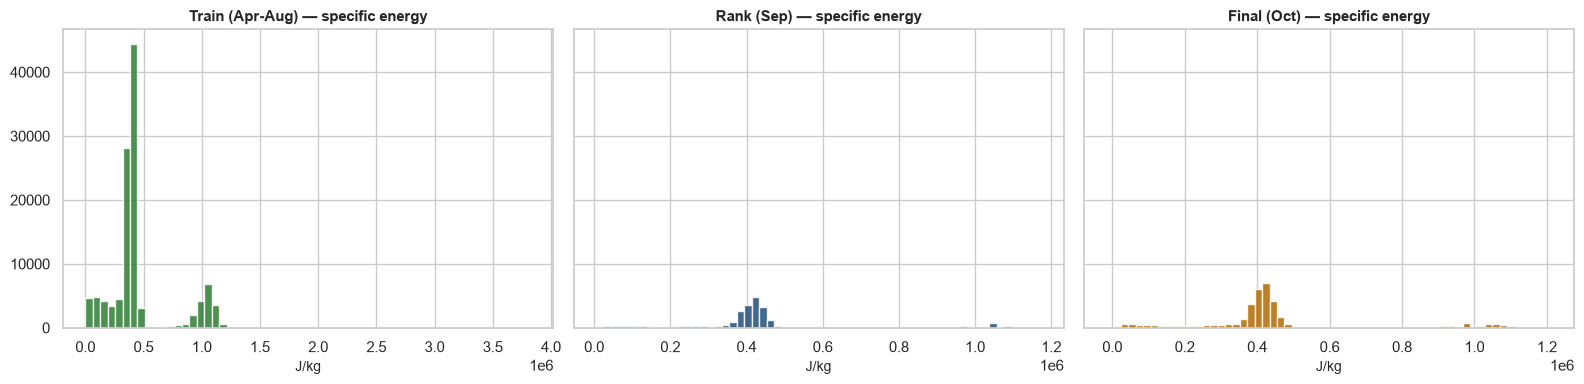

In [144]:

if "mean_specific_energy_jpkg" in df0.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, split in zip(axes, SPLIT_ORDER):
        ax.hist(DATASETS[split]["mean_specific_energy_jpkg"].drop_nulls().to_numpy(),
                bins=60, color=SPLIT_COLOR[split], alpha=0.85)
        ax.set_title(f"{SPLIT_LABEL[split]} — specific energy"); ax.set_xlabel("J/kg")
    fig.tight_layout()



### 6.4 Weather proxies


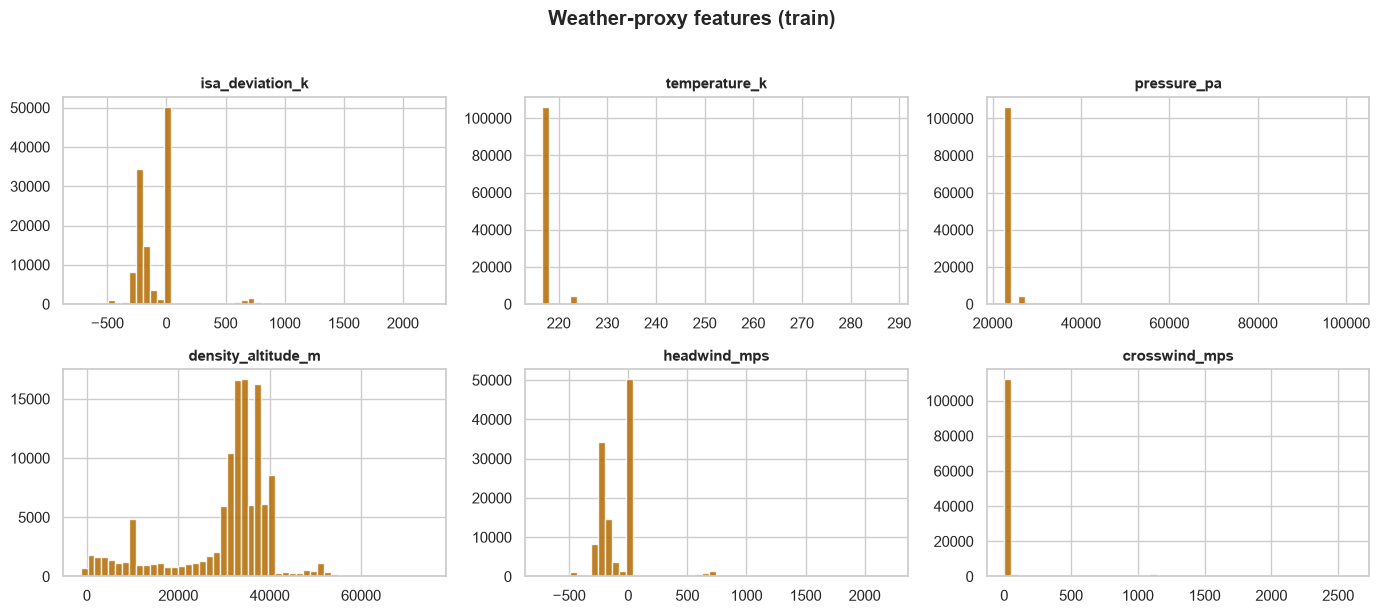

In [145]:

weather_cols = ["isa_deviation_k","temperature_k","pressure_pa","density_altitude_m","headwind_mps","crosswind_mps"]
w = [c for c in weather_cols if c in df0.columns]
dim = len(w)
cols = 3; rows = -(-dim // cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 3*rows))
axes = np.atleast_1d(axes).ravel()
for ax, c in zip(axes, w):
    ax.hist(df0[c].drop_nulls().to_numpy(), bins=50, color="#b26a00", alpha=0.85)
    ax.set_title(c)
for ax in axes[dim:]:
    ax.axis("off")
fig.suptitle("Weather-proxy features (train)", y=1.02, fontweight="bold")
fig.tight_layout()



## 7. R3 dynamic-mass features


### 7.1 Mass across splits (tonnes)


In [146]:

mass_cols = [c for c in df0.columns if c.startswith("r3_")]
if mass_cols:
    print("R3 mass feature set:", mass_cols)
    pd.DataFrame({c: df0[c].drop_nulls().to_pandas().describe() for c in mass_cols[:9]}).T



In [147]:

if "r3_mean_mass_kg" in df0.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, split in zip(axes, SPLIT_ORDER):
        m = DATASETS[split]["r3_mean_mass_kg"].drop_nulls().to_numpy()/1000
        ax.hist(m, bins=60, color=SPLIT_COLOR[split], alpha=0.85)
        ax.set_title(f"{SPLIT_LABEL[split]} — mean mass"); ax.set_xlabel("tonnes")
    fig.tight_layout()



### 7.2 Mass vs aircraft type


In [148]:

if "r3_mean_mass_kg" in df0.columns:
    med = (df0.group_by("aircraft_type").agg(pl.col("r3_mean_mass_kg").median().alias("mass_kg"))
           .sort("mass_kg"))
    plt.figure(figsize=(10, 6))
    sns.barplot(data=med.to_pandas(), y="aircraft_type", x="mass_kg", color="#1f4e79")
    plt.xlabel("median estimated mass (kg)"); plt.title("Median R3 mass by aircraft type")
    plt.tight_layout()



## 8. Outlier & tail analysis


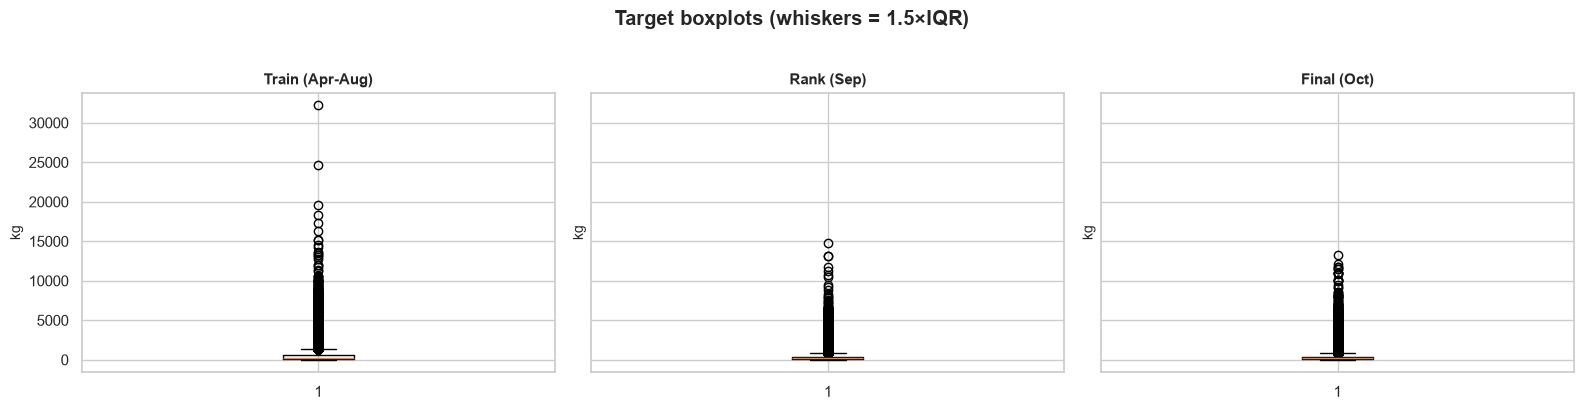

In [149]:

if "actual_fuel_kg" in df0.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, split in zip(axes, SPLIT_ORDER):
        ax.boxplot(DATASETS[split]["actual_fuel_kg"].drop_nulls().to_numpy())
        ax.set_title(f"{SPLIT_LABEL[split]}"); ax.set_ylabel("kg")
    fig.suptitle("Target boxplots (whiskers = 1.5×IQR)", y=1.02, fontweight="bold")
    fig.tight_layout()



In [150]:

# Identify candidate outlier flights (aggregated burn)
if "actual_fuel_kg" in df0.columns:
    flight_burn = df0.group_by("flight_id").agg(pl.col("actual_fuel_kg").sum().alias("total_kg"))
    q99 = flight_burn["total_kg"].quantile(0.99)
    n_extreme = flight_burn.filter(pl.col("total_kg") > q99).height
    print(f"# flights with total burn above 99th pctile = {n_extreme}")
    print(f"99th-pctile total flight burn = {q99:.0f} kg")



# flights with total burn above 99th pctile = 100
99th-pctile total flight burn = 39537 kg


## 9. Train → Rank → Final distribution shift


### 9.1 Covariate-shift table for key features


In [151]:
def shift_table(col: str) -> pd.DataFrame:
    rows = {}
    for split in SPLIT_ORDER:
        df = DATASETS[split]
        if col in df.columns:
            s = df[col]
            rows[SPLIT_LABEL[split]] = {
                "mean": round(float(s.mean()), 2), "std": round(float(s.std()), 2),
                "median": round(float(s.median()), 2),
                "null_frac": round(float(s.null_count())/df.height, 4)}
    out = pd.DataFrame(rows).T
    # relative drift (%) of each split vs train
    if "Train (Apr-Aug)" in rows and rows["Train (Apr-Aug)"]["mean"]:
        base = rows["Train (Apr-Aug)"]["mean"]
        out["drift_vs_train %"] = ((out["mean"] - base) / abs(base) * 100).round(2)
    return out

for c in ["mean_altitude","mean_groundspeed","mean_vertical_rate","duration_s",
          "mean_specific_energy_jpkg","r3_mean_mass_kg"]:
    if c in df0.columns:
        print(f"--- {c} ---")
        print(shift_table(c).to_string())
        print()


--- mean_altitude ---
                     mean       std    median  null_frac  drift_vs_train %
Train (Apr-Aug)  32795.95   9793.19  36989.10     0.0332              0.00
Rank (Sep)       31889.48  10144.74  36001.49     0.0017             -2.76
Final (Oct)      31534.39  10127.23  35996.94     0.0016             -3.85

--- mean_groundspeed ---
                   mean    std  median  null_frac  drift_vs_train %
Train (Apr-Aug)  417.16  79.51  439.18     0.3587              0.00
Rank (Sep)       420.72  80.11  441.51     0.2607              0.85
Final (Oct)      418.69  82.18  441.51     0.2535              0.37

--- mean_vertical_rate ---
                  mean     std  median  null_frac  drift_vs_train %
Train (Apr-Aug) -27.43  812.45   -0.50     0.3587              0.00
Rank (Sep)      -23.98  869.10   -0.35     0.2607             12.58
Final (Oct)     -42.27  873.82   -0.40     0.2535            -54.10

--- duration_s ---
                   mean     std  median  null_frac  drift_vs

## 10. Consolidated dataset summary


In [152]:

summary = []
for split in SPLIT_ORDER:
    df = DATASETS[split]
    summary.append({
        "split": SPLIT_LABEL[split], "intervals": df.height,
        "flights": df["flight_id"].n_unique(),
        "aircraft_types": df["aircraft_type"].n_unique(),
        "origins": df["origin_icao"].n_unique(),
        "routes": df.select(pl.struct(["origin_icao","destination_icao"]).n_unique())[0,0],
        "median_duration_s": round(float(df["duration_s"].median()),0) if "duration_s" in df.columns else None,
        "target_mean_kg": round(float(df["actual_fuel_kg"].mean()),1),
        "target_median_kg": round(float(df["actual_fuel_kg"].median()),1),
        "has_acars_share": round(float(df["has_acars_in_window"].mean()),3),
        "null_cells": int(sum(df[c].null_count() for c in df.columns)),
    })
pd.DataFrame(summary).set_index("split")



,intervals,flights,aircraft_types,origins,routes,median_duration_s,target_mean_kg,target_median_kg,has_acars_share,null_cells
split,,,,,,,,,,
Train (Apr-Aug),119032,10000,26,264,1001,301.0,571.3,217.0,0.888,294022
Rank (Sep),24158,1881,19,138,387,300.0,420.7,163.3,0.974,49571
Final (Oct),37170,2824,21,158,466,300.0,414.2,163.3,0.969,76277
